# 01 · Perfilado y calidad: qué hay en los tres CSV

**Pregunta de partida.** Antes de calcular un solo indicador: ¿qué es exactamente cada archivo, qué le falta y qué supuestos
hay que hacer para leerlo?

**Qué salió de aquí** (y a dónde fue a parar):

- `Transactions` es una **malla completa cliente × mes**: cada cliente tiene una fila por mes, y la mitad de las filas está en 0.
  Un 0 no es "sin fila", es "este mes no se cobró". De aquí nace el **supuesto cero** ("no se cobró", no "no se facturó") del que
  depende toda la lógica de mora (README, *Decisiones de modelado*).
- Enero de 2022 ya tiene **377 clientes pagando**: la serie empieza con clientes preexistentes (censura a la izquierda).
  Por eso la ventana de análisis arranca en **abr-2022** (decisión D4).
- Los montos son múltiplos de una base × 1,05 y el 92 % de los meses consecutivos no cambia: son **suscripciones**, no consumo libre.
- `Industry` cubre el 100 % de los clientes. `S&M` viene como texto con `$`, tiene **PayrollExpenses negativo en 5 meses** y,
  con las unidades del enunciado, equivale a unos **200 MM de COP al mes**.

> Convención de estos notebooks: nunca se muestra el identificador de un cliente. Los ejemplos se imprimen como series anónimas.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
MM = 1e6

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

VIZ = ["#009786", "#8670c0", "#ba673f", "#2b88c0", "#b4608a", "#a28218"]
INK, MUTED, LINE = "#11151A", "#50585B", "#E3E7EC"
plt.rcParams.update({
    "figure.figsize": (9, 3.8), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": LINE, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "font.size": 10,
})


def cifras_publicadas() -> dict:
    """Cifras de app/data/key_figures.csv (las que citan README, HALLAZGOS y NOTA_CORTA) como números."""
    d = pd.read_csv(ROOT / "app" / "data" / "key_figures.csv", dtype=str, keep_default_na=False)
    out = {}
    for k, v in zip(d["cifra"], d["valor"]):
        try:
            out[k] = float(v.replace(".", "").replace(",", ".").replace("−", "-"))
        except ValueError:
            out[k] = v
    return out


KF = cifras_publicadas()


def eje_fechas(*axes):
    """Marcas anuales en los ejes de tiempo."""
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

## 1. `Transactions`: forma, tipos y malla

In [2]:
tx_raw = pd.read_csv(DATA / "Transactions.csv", encoding="utf-8-sig")
print(tx_raw.dtypes.to_string(), "\n")
tx_raw.head(3).assign(ID="…")

ID          int64
month         str
amount    float64 



,ID,month,amount
0,…,1/31/2022,6.3
1,…,2/28/2022,6.3
2,…,3/31/2022,6.3


In [3]:
tx = pd.read_csv(DATA / "Transactions.csv", encoding="utf-8-sig").rename(columns={"ID": "cliente"})
tx["month"] = pd.to_datetime(tx["month"], format="%m/%d/%Y").dt.to_period("M")
tx = tx.sort_values(["cliente", "month"]).reset_index(drop=True)
print(f"{tx['cliente'].nunique()} clientes × {tx['month'].nunique()} meses = {len(tx):,} filas")

1961 clientes × 34 meses = 66,674 filas


In [4]:
n_cli, n_mes = tx["cliente"].nunique(), tx["month"].nunique()
resumen = pd.Series({
    "clientes": n_cli,
    "meses": n_mes,
    "clientes × meses": n_cli * n_mes,
    "filas": len(tx),
    "pares (cliente, mes) duplicados": int(tx.duplicated(["cliente", "month"]).sum()),
    "valores nulos": int(tx.isna().sum().sum()),
    "montos negativos": int((tx["amount"] < 0).sum()),
    "montos en cero": int((tx["amount"] == 0).sum()),
    "% de filas en cero": round((tx["amount"] == 0).mean() * 100, 1),
    "primer mes": str(tx["month"].min()),
    "último mes": str(tx["month"].max()),
    "clientes cuya primera fila es 0 (entran después)": int((tx.groupby("cliente")["amount"].first() == 0).sum()),
    "clientes que terminan en 0": int((tx.groupby("cliente")["amount"].last() == 0).sum()),
})
resumen.to_frame("valor")

,valor
clientes,1961
meses,34
clientes × meses,66674
filas,66674
"pares (cliente, mes) duplicados",0
valores nulos,0
montos negativos,0
montos en cero,33703
% de filas en cero,50.5
primer mes,2022-01


**Lectura.** Filas = clientes × meses, sin duplicados ni nulos: la tabla es una **malla de fechas**, no un registro de
transacciones. El 50 % de las celdas está en 0 porque cada cliente tiene filas desde ene-2022 aunque haya entrado en 2024, y
porque hay meses en 0 **entre** meses pagados. Qué significa ese 0 es la decisión más importante del reto: si fuera "sin servicio",
el modelo de caja de Finora tendría razón; si es "no se cobró", la caja no es MRR. Lo que sigue (notebook 02) muestra por qué la
segunda lectura es la que soportan los datos.

## 2. Los montos son precios de suscripción, no consumo

In [5]:
pos = tx.loc[tx["amount"] > 0, "amount"]
top = pos.round(4).value_counts().head(10).rename("meses-cliente").to_frame()
top["monto ÷ 1,05"] = (top.index / 1.05).round(3)
prev = tx.groupby("cliente")["amount"].shift()
ambos = (tx["amount"] > 0) & (prev > 0)
ratio = tx.loc[ambos, "amount"] / prev[ambos]
print(f"meses pagados consecutivos: {int(ambos.sum()):,} | el monto no cambia en el {np.isclose(ratio, 1).mean():.1%}")
print(f"montos distintos en total: {pos.round(4).nunique()} | los 10 más frecuentes cubren el {top['meses-cliente'].sum() / len(pos):.0%} de los meses pagados")
top

meses pagados consecutivos: 30,542 | el monto no cambia en el 91.7%
montos distintos en total: 1609 | los 10 más frecuentes cubren el 42% de los meses pagados


,meses-cliente,"monto ÷ 1,05"
amount,,
4.20,2417,4.0
6.30,2224,6.0
3.15,1592,3.0
0.63,1331,0.6
5.25,1273,5.0
8.40,1256,8.0
2.10,1142,2.0
7.35,1100,7.0
10.50,878,10.0


**Lectura.** Pocos montos cubren la mayoría de los meses y casi todos son un múltiplo de 1,05 sobre una base redonda
(4,20 = 4 × 1,05; 6,30 = 6 × 1,05; 3,15 = 3 × 1,05). Eso es una **lista de precios con una recarga**, no uso variable. La pista
del enunciado ("suscripciones cuyo valor puede cambiar con el uso") aplica a una minoría: el motor trata como "uso variable" a los
clientes con muchos montos distintos y no les busca subidas de precio.

## 3. La serie empieza con clientes que ya existían

clientes que pagan en ene-2022 (ya existían): 377
clientes cuyo primer pago cae en cada uno de los primeros 6 meses: {'2022-01': 377, '2022-02': 108, '2022-03': 30, '2022-04': 19, '2022-05': 38, '2022-06': 33}


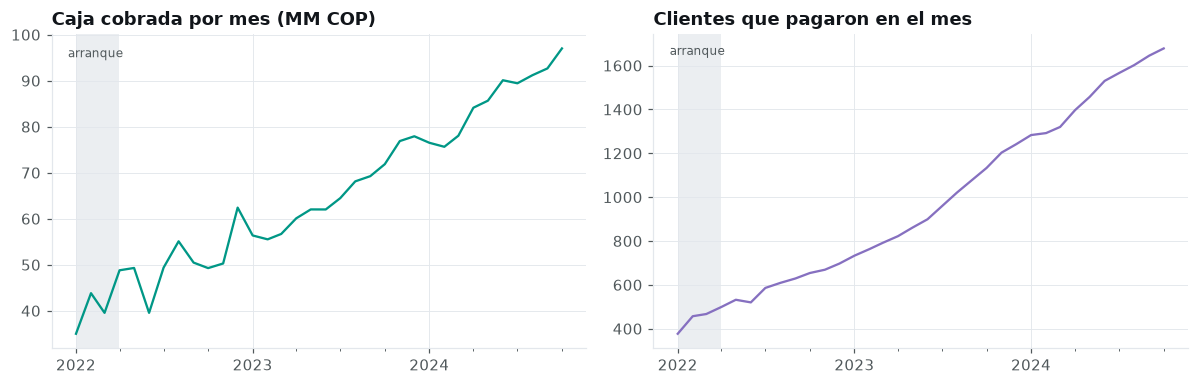

In [6]:
m = tx.groupby("month").agg(caja=("amount", "sum"), pagan=("amount", lambda s: int((s > 0).sum())))
m["caja_MM_COP"] = m["caja"] * 10_000 / MM
primer_pago = tx[tx["amount"] > 0].groupby("cliente")["month"].min()
altas = primer_pago.value_counts().sort_index()
base_inicial = int(m.loc[pd.Period("2022-01", "M"), "pagan"])
print("clientes que pagan en ene-2022 (ya existían):", base_inicial)
print("clientes cuyo primer pago cae en cada uno de los primeros 6 meses:", {str(k): int(v) for k, v in altas.head(6).items()})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
x = m.index.to_timestamp()
ax[0].plot(x, m["caja_MM_COP"], color=VIZ[0]); ax[0].set_title("Caja cobrada por mes (MM COP)")
ax[1].plot(x, m["pagan"], color=VIZ[1]); ax[1].set_title("Clientes que pagaron en el mes")
for a in ax:
    a.axvspan(x[0], pd.Timestamp("2022-03-31"), color=LINE, alpha=0.7, lw=0)
    a.text(pd.Timestamp("2022-02-10"), a.get_ylim()[1] * 0.97, "arranque", ha="center", va="top", fontsize=8, color=MUTED)
eje_fechas(*ax); plt.tight_layout()

**Lectura.** Los 108 "nuevos" de feb-2022 no son nuevos: incluyen clientes antiguos que en enero estaban en un hueco de
pago. Como no se puede distinguir, **ene–mar 2022 es periodo de arranque** y las cifras acumuladas van de abr-2022 a oct-2024.
El criterio es el mismo que el de la regla de mora: quien paga por primera vez dentro de los primeros N + 1 meses pudo ser un
cliente preexistente en mora.

## 4. `Industry`: cobertura completa

In [7]:
ind_raw = pd.read_csv(DATA / "Industry.csv", encoding="utf-8-sig")
print("forma:", ind_raw.shape, "| filas totalmente vacías:", int(ind_raw.isna().all(axis=1).sum()))
ind = ind_raw.dropna(how="all").copy()
ind["cliente"] = ind["ID"].str.extract(r"(\d+)")[0].astype(int)
a, b = set(tx["cliente"]), set(ind["cliente"])
print("clientes sin industria:", len(a - b), "| industrias sin cliente:", len(b - a),
      "| IDs duplicados:", int(ind["cliente"].duplicated().sum()))
ind["Industria"].value_counts().rename("clientes").to_frame()

forma: (1962, 2) | filas totalmente vacías: 1
clientes sin industria: 0 | industrias sin cliente: 0 | IDs duplicados: 0


,clientes
Industria,
Restaurantes,529
Producción,454
Retail,428
Tecnología,241
Servicios profesionales,165
Salud,144


## 5. `S&M_spend`: formato, signos y unidades

formato original de la primera fila: {'Month': '2022-01', 'PaidMedia': '$1.040', 'Travel': '$0.120', 'PublicidadNoWeb': '$0.340', 'Freelance': '$0.100', 'SoftwareTools': '$0.080', 'Team': '$0.240', 'PayrollExpenses': '$0.080'} 

meses con valor negativo, por rubro: {'PayrollExpenses': 5}
Freelance en 0 desde: 2023-05
S&M promedio 2024: 198 MM COP al mes (con S&M × 100.000.000)


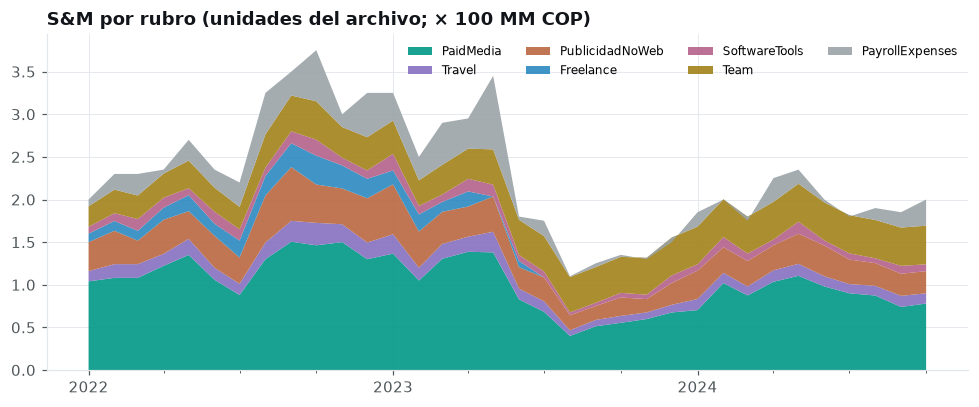

In [8]:
sm_raw = pd.read_csv(DATA / "S&M_spend.csv", encoding="utf-8-sig")
print("formato original de la primera fila:", sm_raw.iloc[0].to_dict(), "\n")
sm = sm_raw.copy()
rubros = [c for c in sm.columns if c != "Month"]
for c in rubros:
    sm[c] = pd.to_numeric(sm[c].astype(str).str.replace("$", "", regex=False), errors="raise")
sm["month"] = pd.PeriodIndex(sm["Month"], freq="M")
sm["total"] = sm[rubros].sum(axis=1)
neg = (sm[rubros] < 0).sum()
print("meses con valor negativo, por rubro:", neg[neg > 0].to_dict())
print("Freelance en 0 desde:", str(sm.loc[sm["Freelance"] == 0, "month"].min()))
sm_2024 = sm.loc[sm["month"].dt.year == 2024, "total"].mean() * 100_000_000
print(f"S&M promedio 2024: {sm_2024 / MM:,.0f} MM COP al mes (con S&M × 100.000.000)")

fig, ax = plt.subplots()
ax.stackplot(sm["month"].dt.to_timestamp(), [sm[c] for c in rubros], labels=rubros, colors=VIZ + ["#9aa3a8"], alpha=0.9)
ax.set_title("S&M por rubro (unidades del archivo; × 100 MM COP)")
ax.legend(ncol=4, fontsize=8, loc="upper right"); eje_fechas(ax)
plt.tight_layout()

**Lectura.** El S&M incluye nómina y equipo (`Team`, `PayrollExpenses`), así que no es solo adquisición. Los negativos de
`PayrollExpenses` se mantienen como ajustes contables y se reportan. Con las unidades del enunciado, el S&M mensual de 2024 ronda
los 200 MM de COP: **el doble del MRR total** (notebook 05). Antes de cualquier decisión de inversión hay que confirmar las unidades
con Finanzas.

## Conclusión: qué es "incompleto a propósito" y qué decisiones salieron de aquí

| Lo que no hay | Consecuencia |
|---|---|
| Precio de lista, plan, descuentos | No se puede separar un descuento de un downgrade (notebook 03) |
| Estado de la suscripción, fecha de cancelación | El churn hay que inferirlo desde los pagos (notebook 02) |
| Marca de "recurrente / mora / ajuste" en cada monto | La caja hay que descomponerla (notebook 04) |
| Eventos del funnel, canal | El Caso 1 se responde solo por el lado "Won" (notebook 05) |

Decisiones alimentadas: **supuesto cero** (0 = no se cobró), **unidades** del enunciado (×10.000 y ×100.000.000),
**ventana desde abr-2022** y reporte de los negativos del S&M sin corregirlos.

In [9]:
assert KF["clientes"] == n_cli and KF["meses"] == n_mes
assert KF["base_inicial"] == base_inicial
assert KF["payroll_neg"] == int((sm["PayrollExpenses"] < 0).sum())
print("coincide con key_figures.csv:", {k: KF[k] for k in ("clientes", "meses", "base_inicial", "payroll_neg")})

coincide con key_figures.csv: {'clientes': 1961.0, 'meses': 34.0, 'base_inicial': 377.0, 'payroll_neg': 5.0}
